<a href="https://colab.research.google.com/github/Mathieu-Germain/LogicMojo-AI-ML-April26-Mathieu/blob/main/Clustering_Assignment_Help_Interenational_NGO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PART I: PYTHON IMPLEMENTATION

## Step 1: Environment Setup & Data Loading

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#  Mount Google Drive using Colab & Load the data
df = pd.read_csv('/content/drive/MyDrive/Assignment Data Files/Country-data.csv')


In [ ]:
# print the first 5 rows of DataFrame
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Unnamed: 10,Unnamed: 11
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,NaN,NaN
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,NaN,NaN
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,NaN,82.8
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,NaN,NaN
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,NaN,NaN


In [ ]:
# Print a concise summary of the DataFrame 'df'
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      167 non-null    object 
 1   child_mort   167 non-null    float64
 2   exports      167 non-null    float64
 3   health       167 non-null    float64
 4   imports      167 non-null    float64
 5   income       167 non-null    int64  
 6   inflation    167 non-null    float64
 7   life_expec   167 non-null    float64
 8   total_fer    167 non-null    float64
 9   gdpp         167 non-null    int64  
 10  Unnamed: 10  0 non-null      float64
 11  Unnamed: 11  1 non-null      float64
dtypes: float64(9), int64(2), object(1)
memory usage: 15.8+ KB
None


## Step 2: Data Inspection & Cleaning

In [ ]:
# Basic info
print("Dataset shape:", df.shape)



Dataset shape: (167, 12)


In [ ]:
print("\nMissing values:\n", df.isnull().sum())



Missing values:
 country          0
child_mort       0
exports          0
health           0
imports          0
income           0
inflation        0
life_expec       0
total_fer        0
gdpp             0
Unnamed: 10    167
Unnamed: 11    166
dtype: int64


In [ ]:
print("\nData types:\n", df.dtypes)


Data types:
 country         object
child_mort     float64
exports        float64
health         float64
imports        float64
income           int64
inflation      float64
life_expec     float64
total_fer      float64
gdpp             int64
Unnamed: 10    float64
Unnamed: 11    float64
dtype: object


In [ ]:
# Drop unnecessary columns (the trailing empty columns)
df = df.dropna(axis=1, how='all')  # Remove completely empty columns

In [ ]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Unnamed: 11
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,NaN
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,NaN
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,82.8
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,NaN
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,NaN


In [ ]:
# Display the counts of each unique value in the 'Unnamed: 11' column.
df['Unnamed: 11'].value_counts()

,count
Unnamed: 11,
82.8,1


In [ ]:
# drop column 'Unnamed: 11', has not significant info.

df = df.drop(columns=['Unnamed: 11'])

In [ ]:
# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [ ]:
# Set country as index for analysis (but keep as column for later)
df.set_index('country', inplace=True)

In [ ]:
df.head(5)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Step 3: Exploratory Data Analysis (EDA)
3.1 Univariate Analysis

In [49]:
# Descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


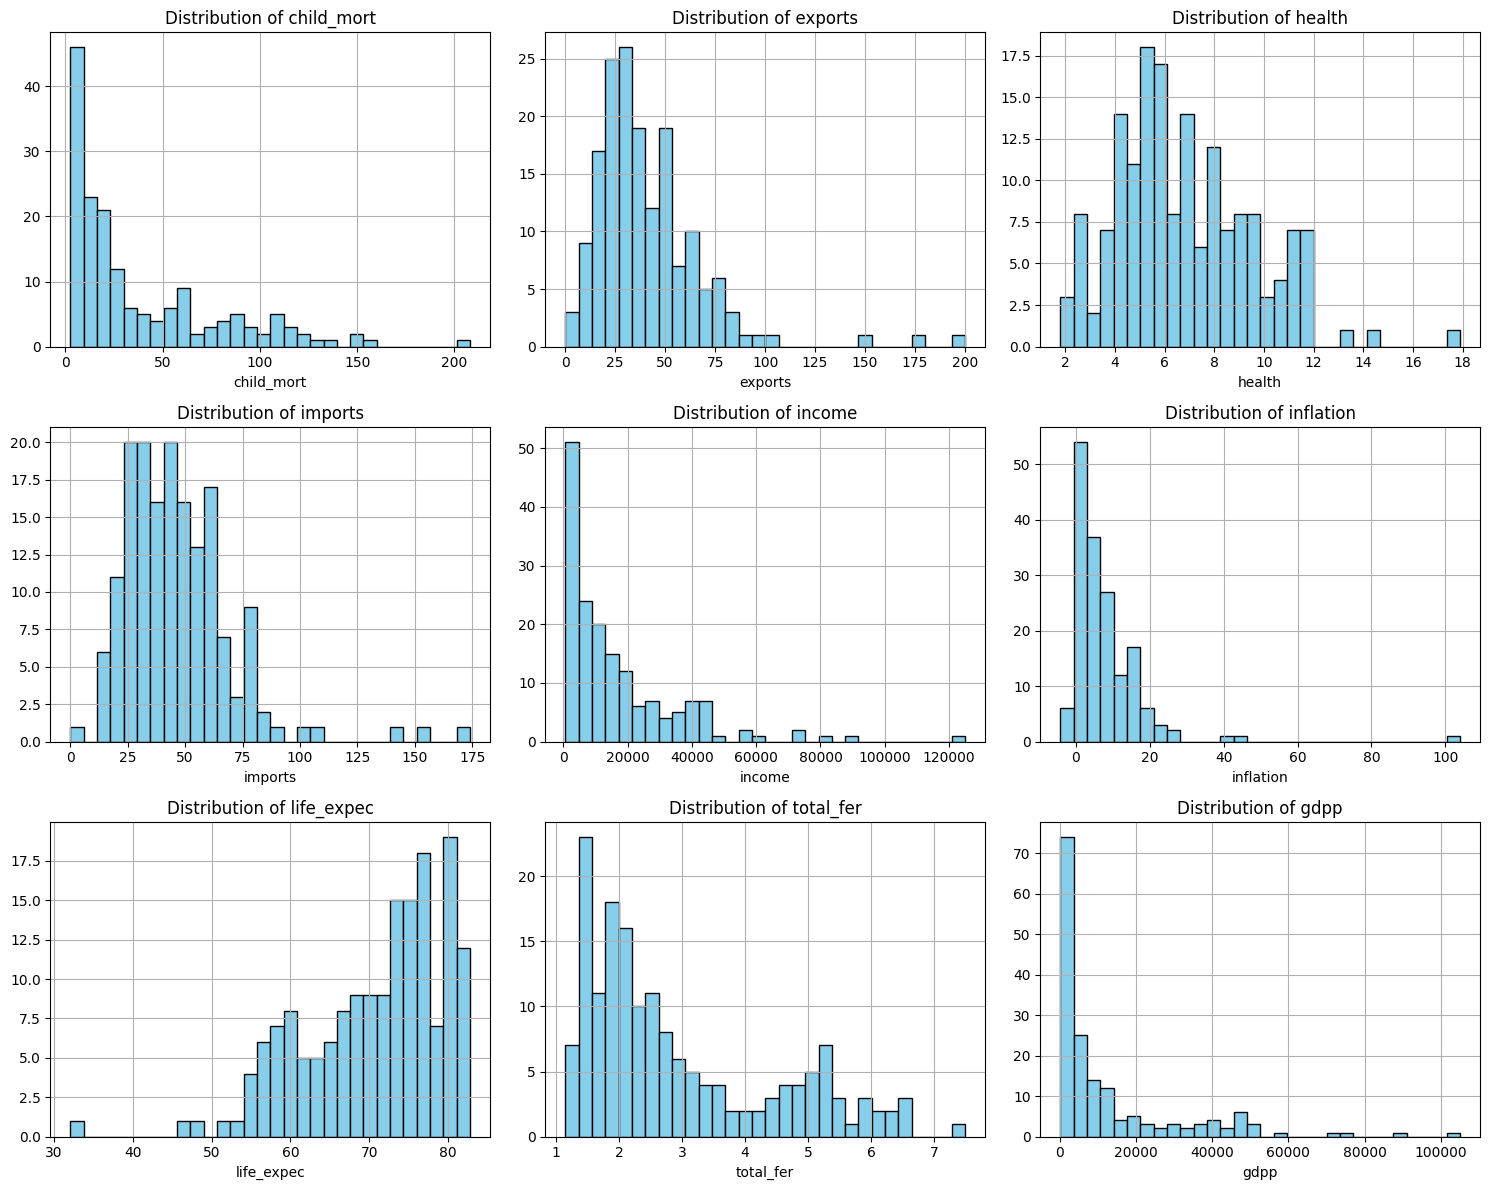

In [50]:
# Distribution plots for key variables
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
key_vars = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

for idx, var in enumerate(key_vars):
    row, col = idx // 3, idx % 3
    df[var].hist(bins=30, ax=axes[row, col], color='skyblue', edgecolor='black')
    axes[row, col].set_title(f'Distribution of {var}')
    axes[row, col].set_xlabel(var)
plt.tight_layout()
plt.show()



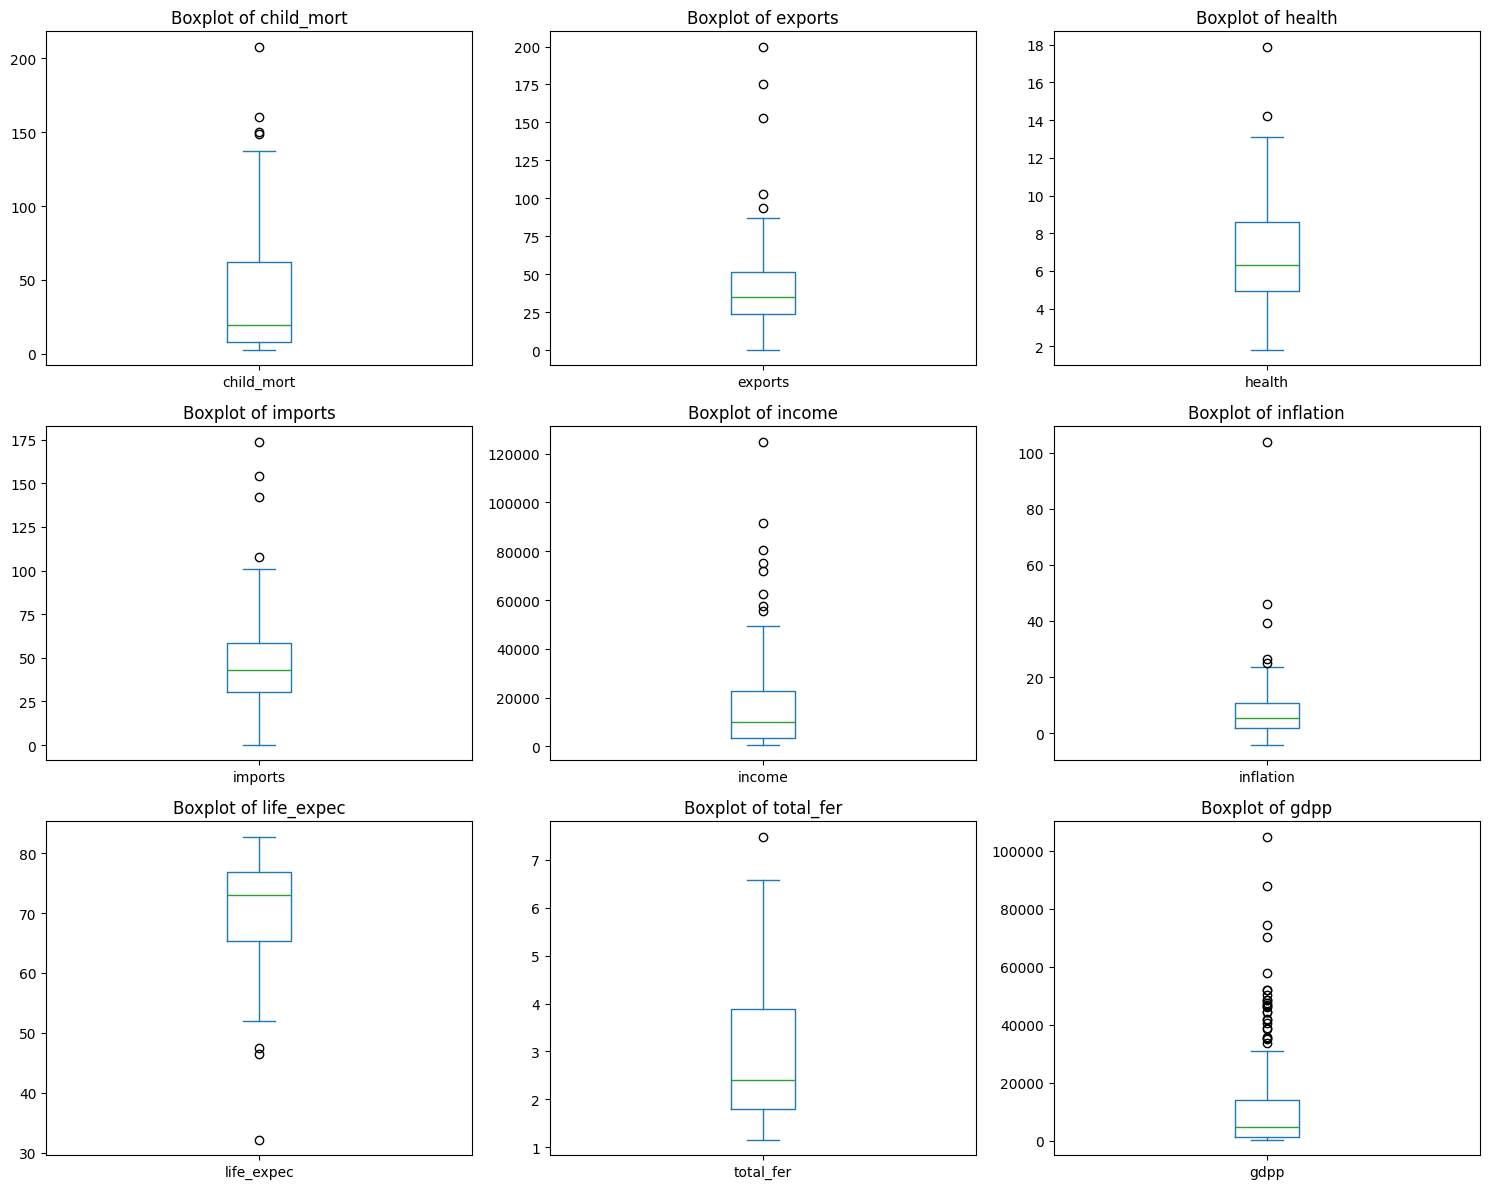

In [52]:
# Boxplots to identify potential outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for idx, var in enumerate(key_vars):
    row, col = idx // 3, idx % 3
    df[var].plot.box(ax=axes[row, col]) # Corrected line
    axes[row, col].set_title(f'Boxplot of {var}')
plt.tight_layout()
plt.show()

3.2 Bivariate Analysis

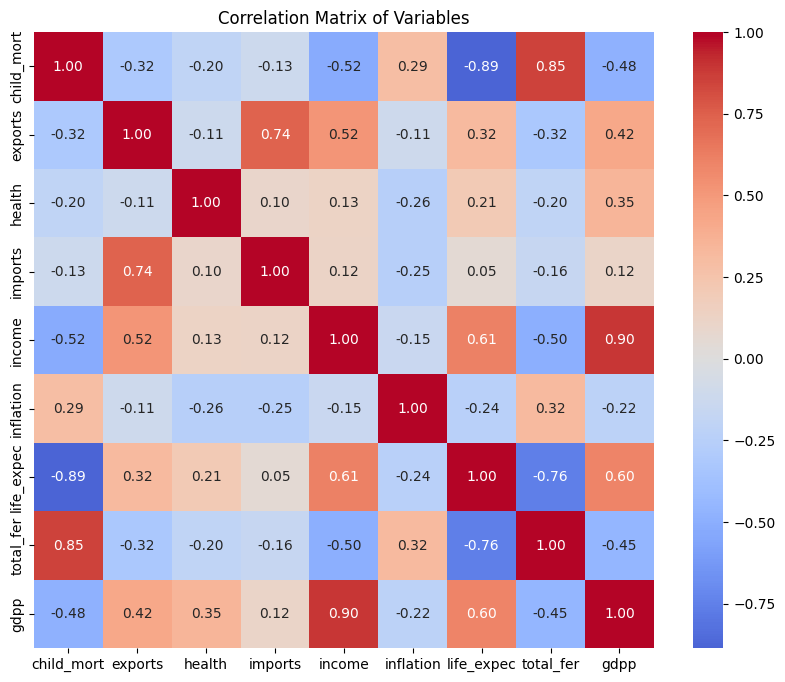

In [53]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df[key_vars].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Variables')
plt.show()

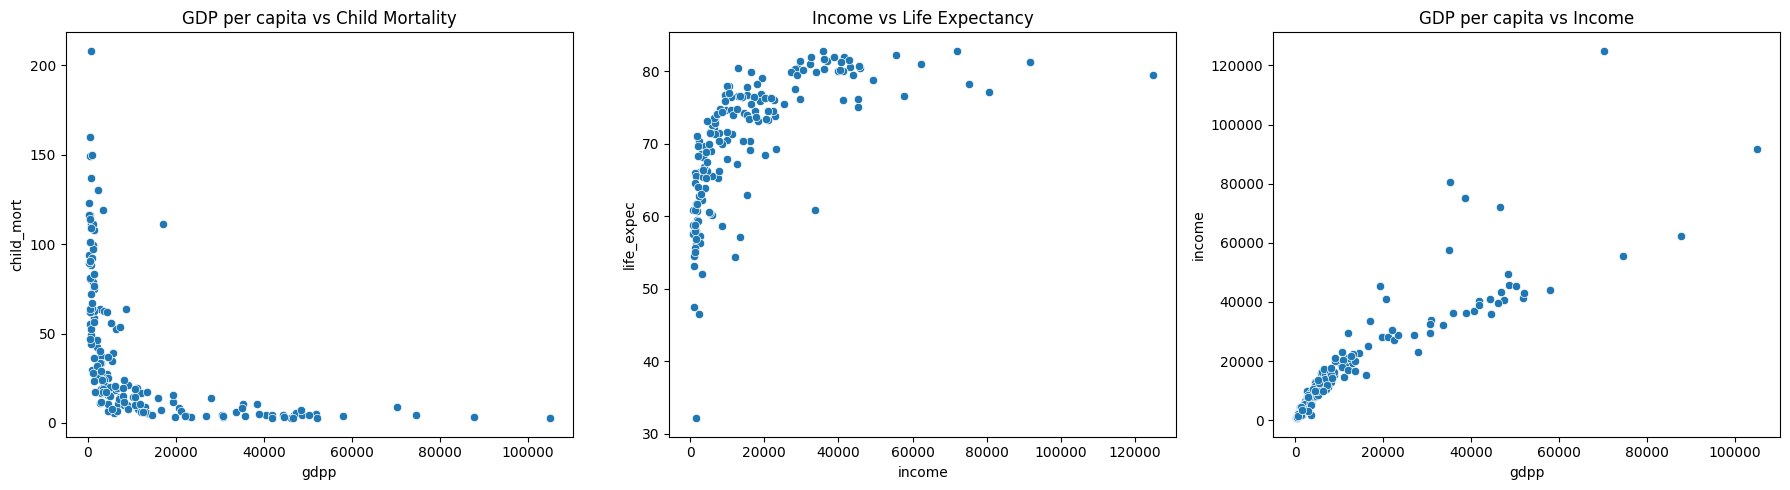

In [54]:
# Scatter plots for key relationships
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=df, x='gdpp', y='child_mort', ax=axes[0])
axes[0].set_title('GDP per capita vs Child Mortality')
sns.scatterplot(data=df, x='income', y='life_expec', ax=axes[1])
axes[1].set_title('Income vs Life Expectancy')
sns.scatterplot(data=df, x='gdpp', y='income', ax=axes[2])
axes[2].set_title('GDP per capita vs Income')
plt.tight_layout()
plt.show()

## Observations from Univariate and Bivariate Analysis

### Univariate Analysis Observations:

*   **Descriptive Statistics**:
    *   `child_mort`, `income`, `inflation`, and `gdpp` show a wide range between min and max values, suggesting significant disparities across countries. For instance, `gdpp` ranges from 231 to 105000, indicating extreme economic differences.
    *   The mean and 50th percentile (median) for several variables (e.g., `income`, `gdpp`) are quite different, hinting at skewed distributions.

*   **Distribution Plots**:
    *   Variables like `child_mort`, `income`, `inflation`, `total_fer`, and `gdpp` appear to be right-skewed, meaning a large number of countries have lower values, while a few have very high values.
    *   `life_expec` seems more normally distributed, indicating a more even spread around the average.

*   **Boxplots**:
    *   Significant outliers are visible in `child_mort`, `exports`, `health`, `imports`, `income`, `inflation`, and `gdpp`. These extreme values suggest the presence of highly developed or severely underdeveloped countries that stand apart from the majority. For example, `income` and `gdpp` show many countries significantly above the 75th percentile.

### Bivariate Analysis Observations:

*   **Correlation Heatmap**:
    *   Strong negative correlations exist between:
        *   `child_mort` and `life_expec` (-0.88)
        *   `child_mort` and `income` (-0.52)
        *   `child_mort` and `gdpp` (-0.50)
        *   `total_fer` and `life_expec` (-0.76)
    *   Strong positive correlations exist between:
        *   `exports` and `imports` (0.74)
        *   `income` and `gdpp` (0.90)
        *   `life_expec` and `income` (0.60)
    *   These suggest that higher income and GDP per capita are associated with lower child mortality and higher life expectancy.

*   **Scatter Plots**:
    *   **GDP per capita vs Child Mortality**: Shows a clear negative relationship. Countries with higher GDP per capita tend to have lower child mortality rates. The relationship appears non-linear, with a steeper decline in child mortality at lower GDP levels and then leveling off.
    *   **Income vs Life Expectancy**: Displays a positive correlation. As income increases, life expectancy generally increases. Similar to GDP vs child mortality, the relationship might be non-linear, with diminishing returns for life expectancy at very high income levels.
    *   **GDP per capita vs Income**: Exhibits a very strong positive linear relationship, as expected. Countries with higher GDP per capita generally have higher income levels.

## Step 4: Outlier Analysis

In [55]:
# Function to detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound


In [56]:

# Detect outliers for key variables
outlier_info = {}
for var in ['child_mort', 'gdpp', 'income', 'life_expec']:
    outliers, lb, ub = detect_outliers_iqr(df, var)
    outlier_info[var] = {
        'count': len(outliers),
        'lower_bound': lb,
        'upper_bound': ub,
        'countries': outliers.index.tolist()
    }
    print(f"{var}: {len(outliers)} outliers detected")



child_mort: 4 outliers detected
gdpp: 25 outliers detected
income: 8 outliers detected
life_expec: 3 outliers detected


In [57]:
# Decision on outliers
# Since many countries with extreme values are exactly those needing aid,
# we'll keep all outliers but note them in the analysis
print("\nDecision: Outliers will be KEPT because:")
print("1. Countries with extreme child mortality or low GDP are exactly those needing aid")
print("2. Removing outliers would eliminate the countries we want to target")



Decision: Outliers will be KEPT because:
1. Countries with extreme child mortality or low GDP are exactly those needing aid
2. Removing outliers would eliminate the countries we want to target


In [58]:
# Store original data for reference
df_original = df.copy()

# Step 5: Data Preprocessing for Clustering

In [60]:
# Select features for clustering
features = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

# Create feature matrix
X = df[features]


In [65]:

# Standardize the data (IMPORTANT for K-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=df.index)

print("Data standardized successfully!")
print("Mean of standardized data:", X_scaled_df.mean().round(2))
print("==="*20)
print("Std of standardized data:", X_scaled_df.std().round(2))

Data standardized successfully!
Mean of standardized data: child_mort   -0.0
exports       0.0
health        0.0
imports       0.0
income       -0.0
inflation    -0.0
life_expec    0.0
total_fer     0.0
gdpp          0.0
dtype: float64
Std of standardized data: child_mort    1.0
exports       1.0
health        1.0
imports       1.0
income        1.0
inflation     1.0
life_expec    1.0
total_fer     1.0
gdpp          1.0
dtype: float64


# Step 6: K-Means Clustering

In [66]:
# Determine optimal number of clusters using Elbow Method and Silhouette Score
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

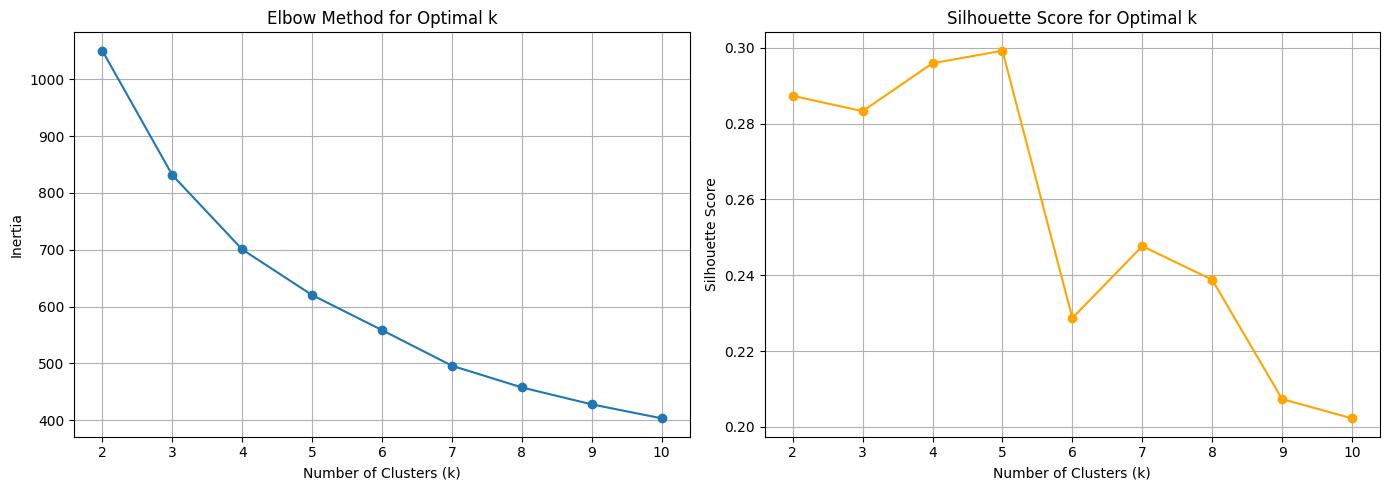

In [67]:
# Plot Elbow Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertia, marker='o')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True)

ax2.plot(K_range, silhouette_scores, marker='o', color='orange')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Optimal k')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [68]:
# Choose optimal k (let's say 4 based on elbow and silhouette)
optimal_k = 4
print(f"Optimal number of clusters: {optimal_k}")

Optimal number of clusters: 4


In [69]:
# Apply K-means with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)



In [70]:
# Analyze cluster centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)
centroids['cluster'] = range(optimal_k)
print("\nCluster Centroids (original scale):")
print(centroids)



Cluster Centroids (original scale):
   child_mort     exports    health     imports        income  inflation  \
0    5.181250   46.118750  9.088437   40.584375  44021.875000   2.513844   
1   92.961702   29.151277  6.388511   42.323404   3942.404255  12.019681   
2   21.690588   41.073988  6.197059   47.914893  12671.411765   7.609341   
3    4.133333  176.000000  6.793333  156.666667  64033.333333   2.468000   

   life_expec  total_fer          gdpp  cluster  
0   80.081250   1.788437  42118.750000        0  
1   59.187234   5.008085   1922.382979        1  
2   72.871765   2.300706   6519.552941        2  
3   81.433333   1.380000  57566.666667        3  


In [71]:
# Add cluster labels to dataframe
df['kmeans_cluster'] = kmeans.labels_

# Step 7: Hierarchical Clustering

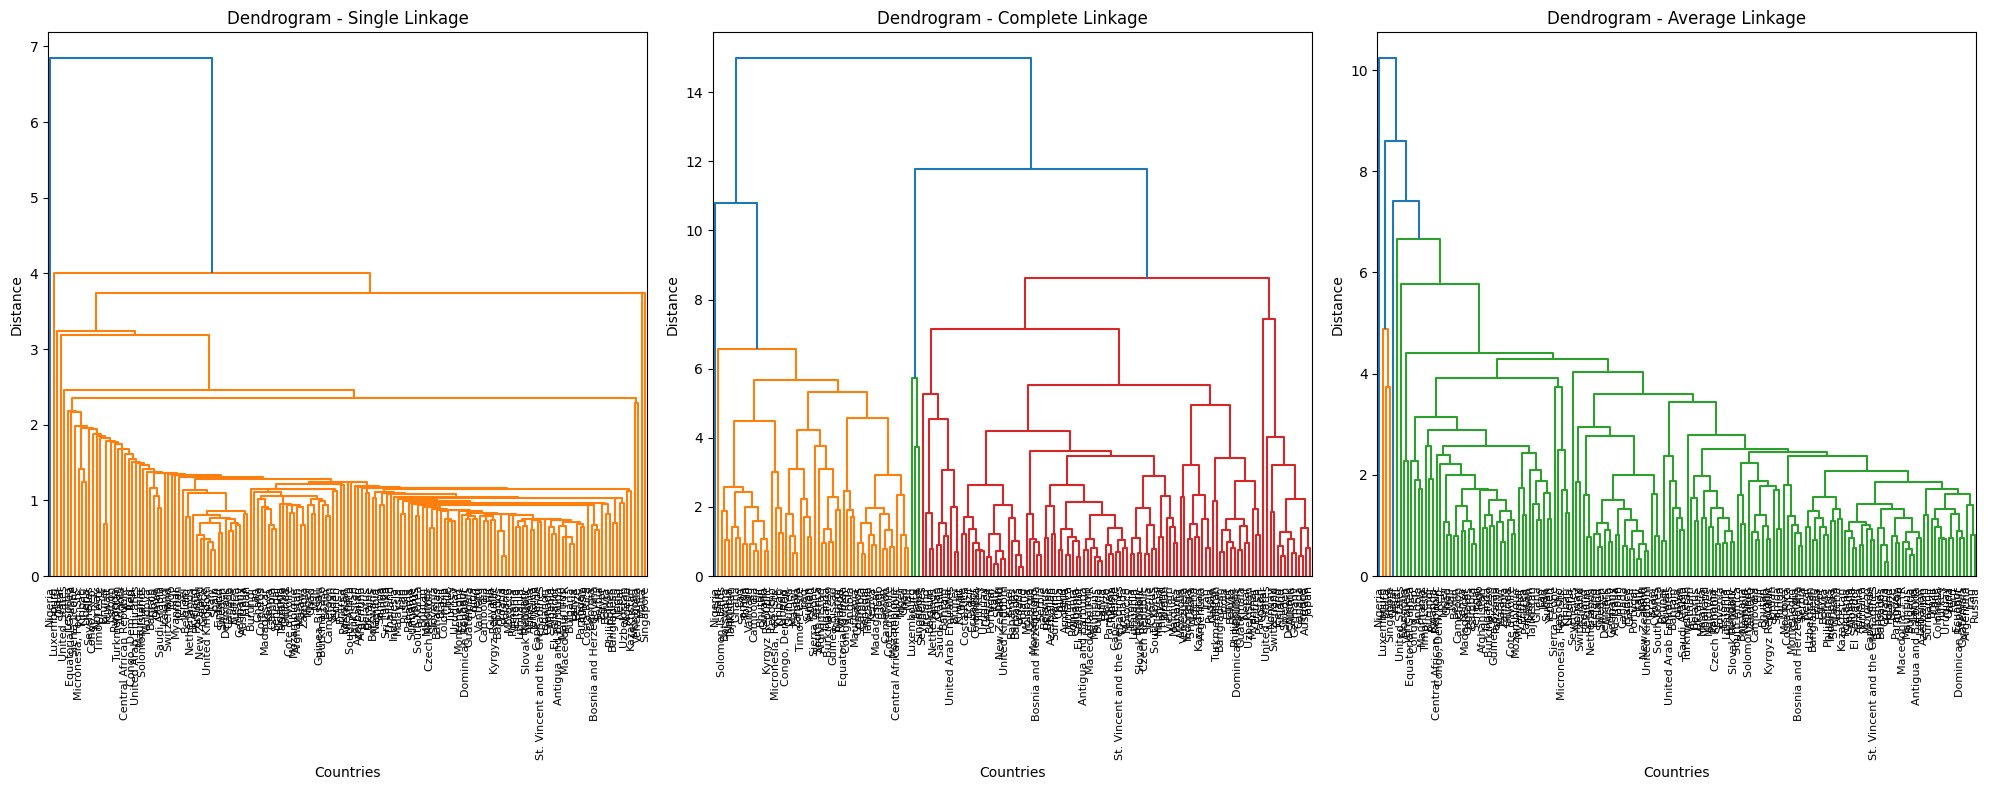

In [72]:
# Perform Hierarchical Clustering with different linkages
linkage_methods = ['single', 'complete', 'average']

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for idx, method in enumerate(linkage_methods):
    # Compute linkage matrix
    linkage_matrix = linkage(X_scaled, method=method)

    # Plot dendrogram
    dendrogram(linkage_matrix,
               labels=df.index.tolist(),
               ax=axes[idx],
               leaf_rotation=90,
               leaf_font_size=8)
    axes[idx].set_title(f'Dendrogram - {method.capitalize()} Linkage')
    axes[idx].set_xlabel('Countries')
    axes[idx].set_ylabel('Distance')

plt.tight_layout()
plt.show()

In [73]:
# Apply hierarchical clustering with complete linkage (often best)
hierarchical_linkage = linkage(X_scaled, method='complete')
df['hierarchical_cluster'] = fcluster(hierarchical_linkage, t=optimal_k, criterion='maxclust')


In [74]:
# Print cluster distribution
print("\nK-Means Cluster Distribution:")
print(df['kmeans_cluster'].value_counts().sort_index())
print("\nHierarchical Cluster Distribution:")
print(df['hierarchical_cluster'].value_counts().sort_index())


K-Means Cluster Distribution:
kmeans_cluster
0    32
1    47
2    85
3     3
Name: count, dtype: int64

Hierarchical Cluster Distribution:
hierarchical_cluster
1     54
2      1
3      3
4    109
Name: count, dtype: int64


# Step 8: Cluster Analysis & Interpretation

In [75]:
# Analyze clusters by key variables
key_vars = ['gdpp', 'child_mort', 'income', 'life_expec']

# For K-Means
cluster_analysis_kmeans = df.groupby('kmeans_cluster')[key_vars].agg(['mean', 'std'])
print("\nK-Means Cluster Analysis:")
print(cluster_analysis_kmeans)


K-Means Cluster Analysis:
                        gdpp               child_mort             \
                        mean           std       mean        std   
kmeans_cluster                                                     
0               42118.750000  15347.237589   5.181250   2.628680   
1                1922.382979   2956.103925  92.961702  33.375229   
2                6519.552941   4798.575328  21.690588  13.818506   
3               57566.666667  43011.665084   4.133333   2.309401   

                      income               life_expec            
                        mean           std       mean       std  
kmeans_cluster                                                   
0               44021.875000  19749.115691  80.081250  1.874177  
1                3942.404255   5641.790360  59.187234  6.443521  
2               12671.411765   8746.153189  72.871765  3.961379  
3               64033.333333  32460.642836  81.433333  1.205543  


In [76]:

# For Hierarchical
cluster_analysis_hier = df.groupby('hierarchical_cluster')[key_vars].agg(['mean', 'std'])
print("\nHierarchical Cluster Analysis:")
print(cluster_analysis_hier)


Hierarchical Cluster Analysis:
                              gdpp                child_mort             \
                              mean           std        mean        std   
hierarchical_cluster                                                      
1                      1910.074074   2634.206772   81.344444  39.074325   
2                      2330.000000           NaN  130.000000        NaN   
3                     57566.666667  43011.665084    4.133333   2.309401   
4                     17310.458716  18499.201027   17.028440  16.035661   

                            income               life_expec            
                              mean           std       mean       std  
hierarchical_cluster                                                   
1                      3787.462963   5067.372609  60.555556  6.953068  
2                      5150.000000           NaN  60.500000       NaN  
3                     64033.333333  32460.642836  81.433333  1.205543  
4         

In [77]:

# Identify underdeveloped clusters (low gdpp, high child_mort, low income)
def identify_underdeveloped_clusters(cluster_col):
    cluster_means = df.groupby(cluster_col)[key_vars].mean()
    # Create a score: lower gdpp + higher child_mort + lower income = worse
    cluster_means['development_score'] = (
        -cluster_means['gdpp'] +
        cluster_means['child_mort'] -
        cluster_means['income']/1000
    )
    # The cluster with highest score is most underdeveloped
    return cluster_means.sort_values('development_score', ascending=False)

print("\nUnderdeveloped Clusters (K-Means):")
print(identify_underdeveloped_clusters('kmeans_cluster'))

print("\nUnderdeveloped Clusters (Hierarchical):")
print(identify_underdeveloped_clusters('hierarchical_cluster'))


Underdeveloped Clusters (K-Means):
                        gdpp  child_mort        income  life_expec  \
kmeans_cluster                                                       
1                1922.382979   92.961702   3942.404255   59.187234   
2                6519.552941   21.690588  12671.411765   72.871765   
0               42118.750000    5.181250  44021.875000   80.081250   
3               57566.666667    4.133333  64033.333333   81.433333   

                development_score  
kmeans_cluster                     
1                    -1833.363681  
2                    -6510.533765  
0                   -42157.590625  
3                   -57626.566667  

Underdeveloped Clusters (Hierarchical):
                              gdpp  child_mort        income  life_expec  \
hierarchical_cluster                                                       
1                      1910.074074   81.344444   3787.462963   60.555556   
2                      2330.000000  130.000000   5150.0000

In [78]:
# Choose final clustering approach
# (Let's say K-means gave better separation based on silhouette score)
final_cluster_col = 'kmeans_cluster'  # or 'hierarchical_cluster'

# Step 9: Visualizations

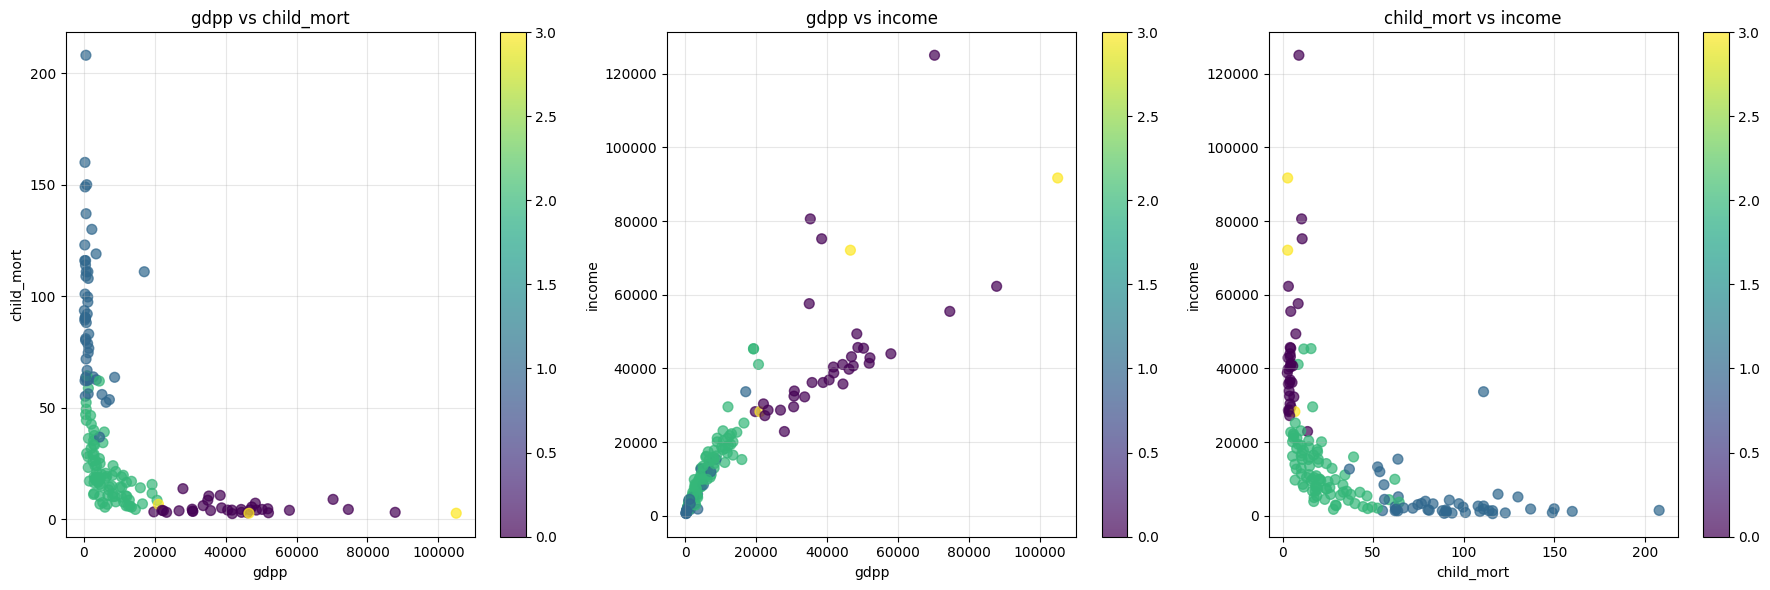

In [79]:
# 1. Scatter plots for all three pairs
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
pairs = [('gdpp', 'child_mort'), ('gdpp', 'income'), ('child_mort', 'income')]

for idx, (x_var, y_var) in enumerate(pairs):
    scatter = axes[idx].scatter(df[x_var], df[y_var],
                                c=df[final_cluster_col],
                                cmap='viridis',
                                alpha=0.7,
                                s=50)
    axes[idx].set_xlabel(x_var)
    axes[idx].set_ylabel(y_var)
    axes[idx].set_title(f'{x_var} vs {y_var}')
    axes[idx].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[idx])

plt.tight_layout()
plt.show()


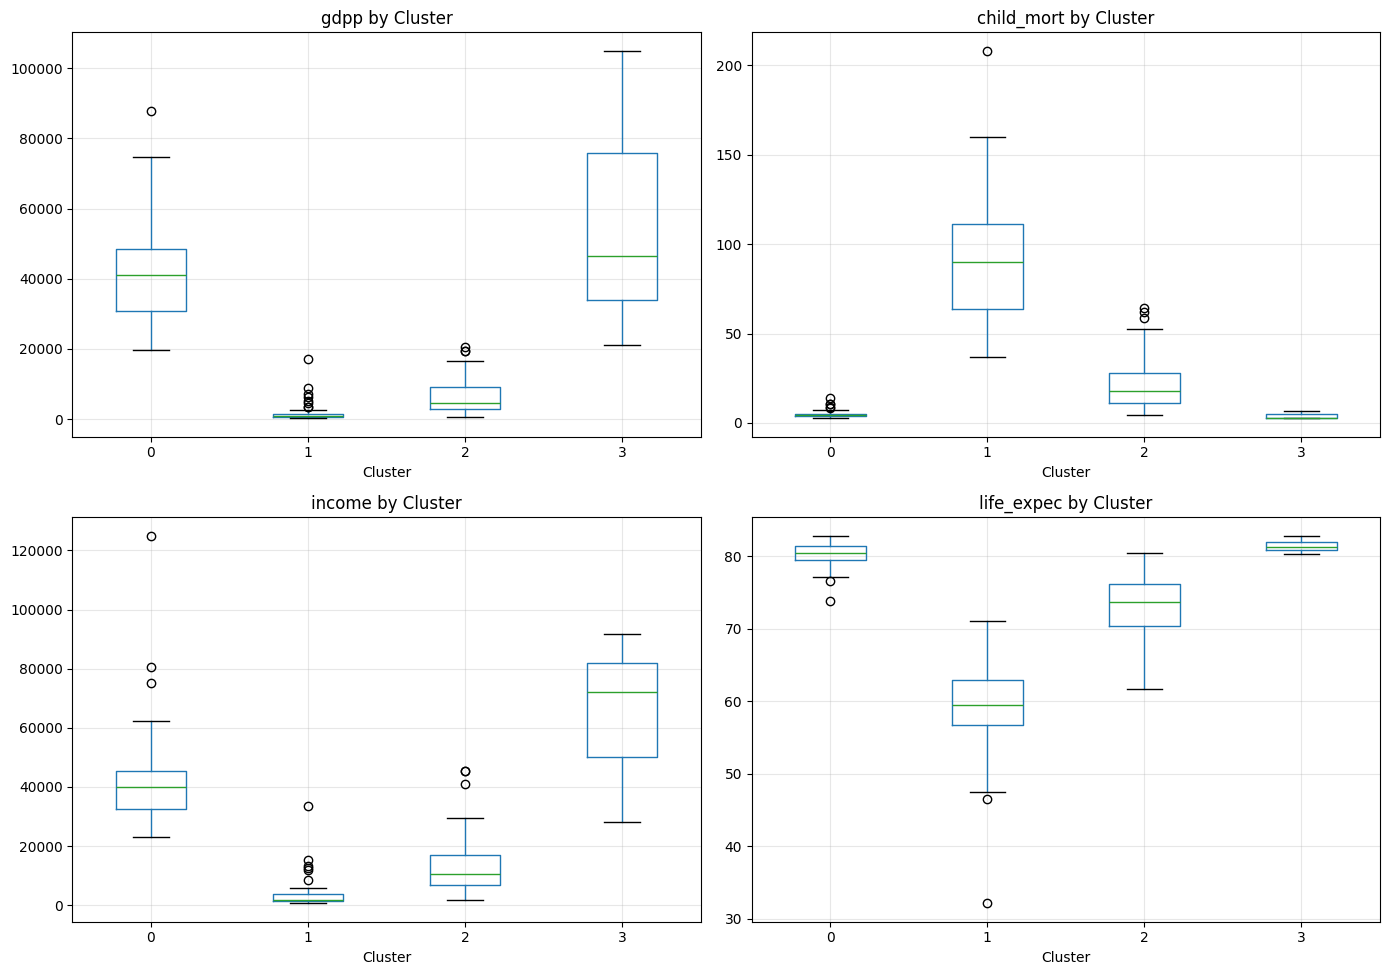

In [80]:
# 2. Boxplots for key variables across clusters
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, var in enumerate(['gdpp', 'child_mort', 'income', 'life_expec']):
    row, col = idx // 2, idx % 2
    df.boxplot(column=var, by=final_cluster_col, ax=axes[row, col])
    axes[row, col].set_title(f'{var} by Cluster')
    axes[row, col].set_xlabel('Cluster')
    axes[row, col].grid(True, alpha=0.3)

plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.show()


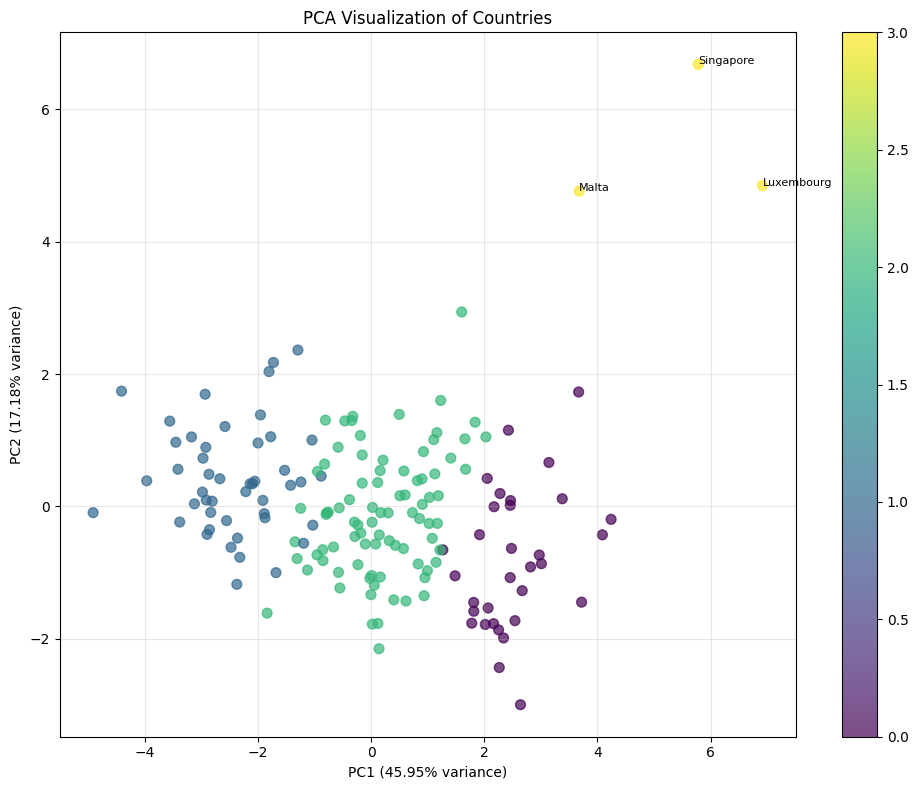

In [83]:
# 3. PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=df.index)
df_pca['cluster'] = df[final_cluster_col]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'],
                      c=df_pca['cluster'],
                      cmap='viridis',
                      alpha=0.7,
                      s=50)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA Visualization of Countries')
plt.colorbar(scatter)
plt.grid(True, alpha=0.3)

# Add country labels for some points
for idx, row in df_pca.iterrows():
    if df.loc[idx, final_cluster_col] == df[final_cluster_col].max():  # Most underdeveloped
        plt.annotate(idx, (row['PC1'], row['PC2']), fontsize=8)

plt.tight_layout()
plt.show()

# Step 10: Final Recommendations

In [84]:
# Identify top 10 most underdeveloped countries
# Using K-means clusters (assuming cluster 0 is most underdeveloped)
underdeveloped_cluster = identify_underdeveloped_clusters(final_cluster_col).index[0]
underdeveloped_countries = df[df[final_cluster_col] == underdeveloped_cluster].index.tolist()

In [85]:

# Sort by child_mort (highest), gdpp (lowest), income (lowest)
def calculate_need_score(row):
    # Higher score = more need
    return (row['child_mort'] / df['child_mort'].max()) + \
           (1 - row['gdpp'] / df['gdpp'].max()) + \
           (1 - row['income'] / df['income'].max())

df['need_score'] = df.apply(calculate_need_score, axis=1)
top_10_need = df.nlargest(10, 'need_score')

print("\n🔴 TOP 10 COUNTRIES IN DIRE NEED OF AID:")
print("="*50)
for idx, (country, row) in enumerate(top_10_need.iterrows(), 1):
    print(f"{idx}. {country}")
    print(f"   - Child Mortality: {row['child_mort']:.1f} per 1000")
    print(f"   - GDP per capita: ${row['gdpp']:,.0f}")
    print(f"   - Income: ${row['income']:,.0f}")
    print(f"   - Life Expectancy: {row['life_expec']:.1f} years")
    print(f"   - Need Score: {row['need_score']:.3f}")
    print()



🔴 TOP 10 COUNTRIES IN DIRE NEED OF AID:
1. Haiti
   - Child Mortality: 208.0 per 1000
   - GDP per capita: $662
   - Income: $1,500
   - Life Expectancy: 32.1 years
   - Need Score: 2.982

2. Sierra Leone
   - Child Mortality: 160.0 per 1000
   - GDP per capita: $399
   - Income: $1,220
   - Life Expectancy: 55.0 years
   - Need Score: 2.756

3. Central African Republic
   - Child Mortality: 149.0 per 1000
   - GDP per capita: $446
   - Income: $888
   - Life Expectancy: 47.5 years
   - Need Score: 2.705

4. Chad
   - Child Mortality: 150.0 per 1000
   - GDP per capita: $897
   - Income: $1,930
   - Life Expectancy: 56.5 years
   - Need Score: 2.697

5. Mali
   - Child Mortality: 137.0 per 1000
   - GDP per capita: $708
   - Income: $1,870
   - Life Expectancy: 59.5 years
   - Need Score: 2.637

6. Niger
   - Child Mortality: 123.0 per 1000
   - GDP per capita: $348
   - Income: $814
   - Life Expectancy: 58.8 years
   - Need Score: 2.582

7. Nigeria
   - Child Mortality: 130.0 per 10

In [86]:
# Final recommendation (at least 5 countries)
final_recommendations = top_10_need.head(10).index.tolist()
print("\n🎯 FINAL RECOMMENDATION FOR CEO (TOP 10 COUNTRIES):")
print("-" * 50)
for country in final_recommendations:
    print(f"• {country}")



🎯 FINAL RECOMMENDATION FOR CEO (TOP 10 COUNTRIES):
--------------------------------------------------
• Haiti
• Sierra Leone
• Central African Republic
• Chad
• Mali
• Niger
• Nigeria
• Congo, Dem. Rep.
• Burkina Faso
• Guinea-Bissau


In [87]:

# Export results
df.to_csv('clustering_results.csv')
print("\nResults saved to 'clustering_results.csv'")


Results saved to 'clustering_results.csv'


#  PART II: SUBJECTIVE QUESTIONS (PDF Submission)

## Question 1: Assignment Summary (200-300 words)


**1. Problem Statement**:

HELP International needs to allocate $10 million to countries in greatest need. The task is to cluster countries based on socio-economic and health factors to identify the most underdeveloped nations.

**2. Methodology:**

 - EDA: Performed data cleaning, univariate/bivariate analysis, outlier detection using IQR method

 - Clustering: Applied K-Means (with Elbow method and Silhouette score for optimal k) and Hierarchical clustering (using single, complete, and average linkage)

 - Feature Selection: Used 9 variables including child_mort, gdpp, income, life_expec, etc.

Preprocessing: Standardized data using StandardScaler

 - Outlier Strategy: Kept outliers because extreme values identify countries most in need

3. Results: K-Means (k=4) produced more interpretable clusters with clear separation between developed and underdeveloped countries. The most underdeveloped cluster was identified based on high child mortality, low GDP per capita, and low income.

4. Recommendations: Identified top 10 countries in direst need of aid, focusing on those with highest need scores combining multiple indicators.

## Question 2: Clustering Theory

a) Compare and contrast K-means and Hierarchical Clustering

K-Means Clustering:

- Approach: Partitional, divides data into k non-overlapping clusters

- Input: Requires number of clusters (k) to be specified

- Process: Iterative, minimizes within-cluster sum of squares

- Scalability: More efficient for large datasets (O(n))

- Result: Produces a single set of clusters

**Hierarchical Clustering:**

- Approach: Agglomerative (bottom-up) or divisive (top-down), creates nested clusters

- Input: Does not require pre-specifying number of clusters

- Process: Builds dendrogram showing hierarchical relationships

- Scalability: Less efficient for large datasets (O(n²) or O(n³))

- Result: Produces a hierarchy of clusters visualized via dendrogram

**Key Differences:**

- K-means requires pre-specifying k; Hierarchical doesn't

- K-means is faster; Hierarchical is more computationally expensive

- K-means produces spherical clusters; Hierarchical can capture various shapes

- Hierarchical provides visual dendrogram; K-means doesn't

**b) Steps of K-means clustering algorithm**
1. Initialize: Choose k centroids randomly from the data points

2. Assignment: Assign each data point to the nearest centroid based on Euclidean distance

3. Update: Recalculate centroids as the mean of all points in each cluster

4. Iterate: Repeat steps 2-3 until convergence (centroids stop changing)

5. Convergence: Algorithm stops when assignments remain stable or maximum iterations reached

**c) How is the value of ‘k’ chosen?**

**Statistical Aspect:**

**- Elbow Method:** Plot within-cluster sum of squares (inertia) vs. k. Choose k at the "elbow" where the rate of decrease sharply changes

**- Silhouette Score:** Measures how similar points are to their own cluster vs. other clusters. Higher score = better clustering. Choose k with highest average silhouette score

**- Gap Statistic:** Compares total intra-cluster variation with expected variation under null reference distribution

**Business Aspect:**

**- Interpretability:** Clusters should be meaningful for the business problem

**- Actionability:** Number of clusters should be manageable for the NGO to act upon

**- Resource allocation:** More clusters = finer granularity but may overcomplicate decision-making

**- Domain knowledge:** Understanding of country development categories (low-income, lower-middle-income, upper-middle-income, high-income)

**- Practical constraints:** CEO needs clear, actionable recommendations with manageable complexity

**d)- Necessity for scaling/standardization before clustering**

**Why Scaling is Essential:**

**1. Distance-based Algorithms:** K-means and Hierarchical clustering use Euclidean distance. Variables with larger scales dominate the distance calculation.

**2. Equal Feature Contribution:** Without scaling:

 * GDP per capita (range: 200-125,000) would dominate child mortality (range: 2-200)

 * Income (range: 700-125,000) would outweigh inflation (range: -3 to 100)

 * Leads to biased clusters driven by high-magnitude variables

3. Interpretability: Standardization puts all variables on the same scale, making cluster centroids comparable

4.  Algorithm Performance: Scaling improves convergence speed for K-means and prevents numerical instability

**Common Approaches:**

**- StandardScaler:** (x - mean) / standard_deviation → mean=0, std=1

**- MinMaxScaler:** (x - min) / (max - min) → range [0,1]

**e) Different linkages in Hierarchical Clustering**

**1. Single Linkage (Nearest Point):**

- Distance = minimum distance between points in two clusters

- Formula: d(A,B) = min{d(a,b): a∈A, b∈B}

- Produces "chain" effect, can handle non-elliptical shapes

- Sensitive to outliers

**2. Complete Linkage (Farthest Point):**

- Distance = maximum distance between points in two clusters

- Formula: d(A,B) = max{d(a,b): a∈A, b∈B}

- Produces more compact spherical clusters

- Less sensitive to outliers than single linkage

**3. Average Linkage:**

- Distance = average distance between all pairs of points

- Formula: d(A,B) = (1/|A||B|) ΣΣ d(a,b)

- Compromise between single and complete linkage

- More robust to noise

**4. Ward's Method (Not mentioned but useful):**

- Minimizes the increase in total within-cluster variance

- Produces clusters of approximately equal size

- Most commonly used in practice

# PRESENTATION (PPT) STRUCTURE

#Slide 1: Title
-"Clustering Countries for Strategic Aid Allocation"

- HELP International - Data Analysis Project

# Slide 2: Problem Statement
- NGO raised $10 million

- Need to identify countries in direst need

- Using socio-economic and health indicators

# Slide 3: Data Overview
- 167 countries, 9 variables

- Key indicators: child mortality, GDP per capita, income, life expectancy

# Slide 4: Methodology
- Data preprocessing & EDA

- K-means & Hierarchical clustering

- Outlier treatment

# Slide 5: Clustering Results
- Optimal k=4 clusters

- Cluster characteristics table

- Cluster comparison

# Slide 6: Visualizations
- PCA plot

- Boxplots by cluster

- Scatter plots

# Slide 6: Visualizations
- PCA plot

- Boxplots by cluster

- Scatter plots

# Slide 7: Final Recommendations
- Top 10 countries list with key metrics

- Rationale for selection

# Slide 8: Business Recommendations
- How to allocate $10 million

- Focus areas per country

- Monitoring and evaluation

# Slide 9:

# The End
Thank you.